<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.3763 acc 0.629 | val loss 0.7149 acc 0.719 *


[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.2141 acc 0.674 | val loss 0.7134 acc 0.772 *


[InceptionNet v3] Epoch   3/100 | LR: 2.85e-04 | train loss 1.1957 acc 0.699 | val loss 0.6706 acc 0.772 *


[InceptionNet v3] Epoch   4/100 | LR: 2.85e-04 | train loss 1.1050 acc 0.719 | val loss 0.6613 acc 0.728 *


[InceptionNet v3] Epoch   5/100 | LR: 2.85e-04 | train loss 1.0842 acc 0.707 | val loss 0.5302 acc 0.778 *


...

[InceptionNet v3] Epoch  42/100 | LR: 2.85e-05 | train loss 0.2009 acc 0.950 | val loss 0.4944 acc 0.834


[InceptionNet v3] Epoch  43/100 | LR: 2.85e-05 | train loss 0.1494 acc 0.969 | val loss 0.4513 acc 0.853


[InceptionNet v3] Epoch  44/100 | LR: 2.85e-05 | train loss 0.1737 acc 0.961 | val loss 0.4696 acc 0.850


[InceptionNet v3] Epoch  45/100 | LR: 2.85e-05 | train loss 0.1631 acc 0.967 | val loss 0.4821 acc 0.844


[InceptionNet v3] Epoch  46/100 | LR: 2.85e-05 | train loss 0.1301 acc 0.963 | val loss 0.4537 acc 0.863

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 46.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3684)


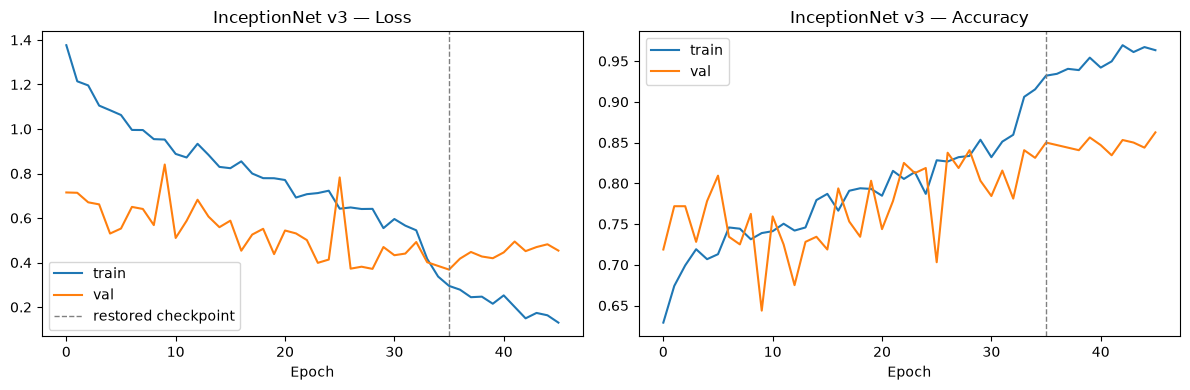

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.735


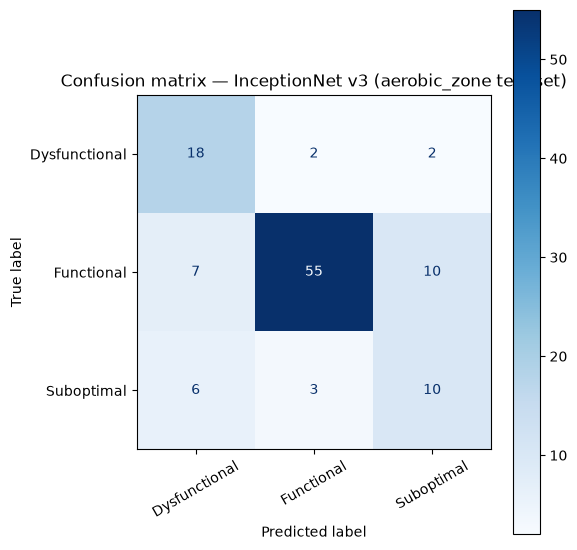

               precision    recall  f1-score   support

Dysfunctional      0.581     0.818     0.679        22
   Functional      0.917     0.764     0.833        72
   Suboptimal      0.455     0.526     0.488        19

     accuracy                          0.735       113
    macro avg      0.651     0.703     0.667       113
 weighted avg      0.774     0.735     0.745       113



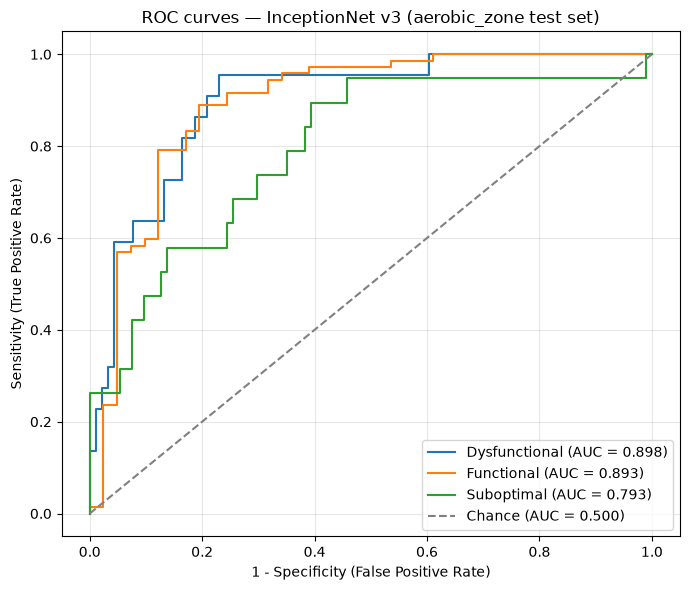

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.898
  Functional     : 0.893
  Suboptimal     : 0.793

Mean AUC (over 3/3 classes with test examples): 0.861


(np.float64(0.7345132743362832),
 {'Dysfunctional': 0.8981018981018981,
  'Functional': 0.8926151761517616,
  'Suboptimal': 0.7928331466965285})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_inception_v3_Atlantis.pkl
Saved model weights to ../models/aerobic_zone_inception_v3_cnn.pt
